# 25_02 이상탐지와 통계 기초

In [53]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 정상 데이터의 평균·표준편차
### 목표
정상 데이터만 골라 중심인 평균과 산포인 표준편차를 구하기
### 단계
- 정답이 정상인 행만 골라내기
- 정상 데이터의 평균을 구해 중심 확인
- 정상 데이터의 표준편차를 구해 흩어짐 확인
### 예상 결과
정상 96개, 평균 약 0.1015, 표준편차 약 0.0184

In [54]:
# 실습1 코드
# CSV 파일 불러오기
df = pd.read_csv("../csv/25_mimii_features.csv")

# 정상
normal = df[df["label"] == 0]
normal.head()
# reset_index 를 통해 정상 데이터의 index 이 재설정해 주는게 좋지만 여기서는 하지 않겠음

normal.describe()

# 정상 개수세기
print("정상 개수 : ", len(normal))
print("평균 : ", round(normal["rms"].mean(), 4))
print("표준편차 : ", round(normal["rms"].std(),4))

정상 개수 :  96
평균 :  0.1015
표준편차 :  0.0184


## 실습 2. 정상 범위 계산 (평균±3σ)
### 목표
정상 평균에 표준편차 세 배를 더하고 빼 정상으로 볼 범위를 정하기
### 단계
- 정상 데이터의 평균과 표준편차를 준비
- 평균에서 표준편차 세 배만큼 아래·위로 벌려 범위를 만들기
- 이 범위를 벗어난 값을 이상 후보로 보기
### 예상 결과
정상 범위 약 0.046~0.157, 이 밖이면 이상 후보


In [55]:
# 실습2 코드

m = normal["rms"].mean()
s = normal["rms"].std()

low = m - s * 3
high = m + s * 3

print("정상 범위 : ", round(low,3), "~", round(high,3))
# 정상 범위 :  0.046 ~ 0.157

# 현장 값하고 비교해야됨 안 맞으면 의미 없음
# 0.6196 인덱스 0번을 보면 값이 다르니 이상값 1이었던 것을 알 수 있음

abnormal = df[(df["rms"] < low) | (df["rms"] > high)]
print(abnormal)

정상 범위 :  0.046 ~ 0.157
       rms  spectral_centroid  zero_crossing_rate  label
0   0.6196             2906.2              0.2283      1
10  0.3925             2675.1              0.1978      1
16  0.4950             2845.9              0.2089      1
19  0.5158             2953.3              0.2280      1
37  0.5098             2806.8              0.2248      1
56  0.4470             2939.8              0.1991      1
68  0.5301             2899.3              0.2541      1
78  0.4984             2946.9              0.2383      1


### 실습 3. 분포 히스토그램·박스플롯 관찰
### 목표
히스토그램과 박스플롯으로 데이터 분포와 튀는 값을 관찰
### 단계
- 한 특징의 히스토그램을 그려 값이 몰린 위치 보기
- 같은 특징의 박스플롯을 그려 상자 밖 점 확인
- 정상은 몰리고 이상은 꼬리로 떨어짐을 관찰
### 예상 결과
정상은 낮은 값에 몰리고, 이상은 오른쪽 꼬리로 떨어져 나옴

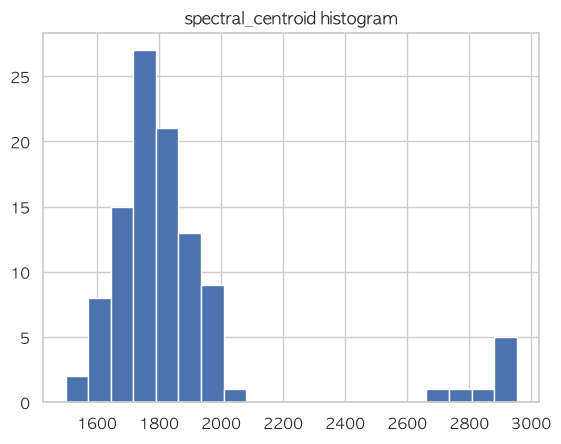

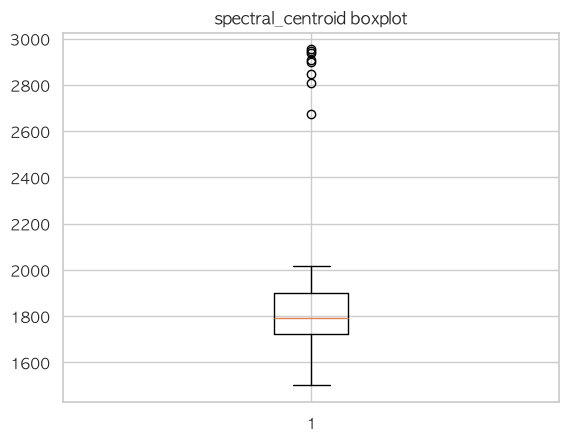

In [56]:
# 실습3 코드

# 히스토그램
plt.hist(df["spectral_centroid"], bins = 20)
plt.title("spectral_centroid histogram")
plt.show()

# 박스플롯
plt.boxplot(df["spectral_centroid"])
plt.title("spectral_centroid boxplot")
plt.show()

## 실습 4. 센서별 정상·이상 통계 비교
### 목표
특징마다 정상 그룹과 이상 그룹의 평균을 비교해 감별력을 보기
### 단계
· 정답이 이상인 행만 따로 골라내기
· 세 특징마다 정상 평균과 이상 평균을 나란히 출력
· 두 평균 차이가 큰 특징을 좋은 감별 특징으로 선별
### 예상 결과
세 특징 모두 이상 평균이 크게 높아 잘 갈림


In [57]:
# 실습4 코드
normal = df[df['label'] == 0]
abnormal = df[df['label'] == 1]

for col in ["rms", "spectral_centroid", "zero_crossing_rate"]:
    print(col, "정상 :", round(normal[col].mean(), 3))
    print("이상 :", round(abnormal[col].mean(), 3))

rms 정상 : 0.101
이상 : 0.501
spectral_centroid 정상 : 1784.023
이상 : 2871.663
zero_crossing_rate 정상 : 0.081
이상 : 0.222
